

#### Análisis y Procesamiento de Señales

# Trabajo Práctico Nº3
#### Angel Joseph Vargas Martinez


# Introducción
### Desparramo Espectral
El desparramo espectral aparece cuando la frecuencia de la senoidal no coincide exactamente con un multiplo entero de la resolucion de DFT($ Δf=F_s/N$), es decir si la frecuencia es exactamente un múltiplo de $Δf$ ($k_0=N/4$) la DFT muestra un pico limpio en un solo bin pero si la frecuencia es un poco mayor o menor  ($k_0 + 0,25 $ o $k_0 + 0,5$) la DFT ya no puede “captarla” en un bin exacto, y distribuye la energia en un lóbulo principal más varios lóbulos laterales.

### Potencia normalizada

Si una señal tiene más o menos amplitud su potencia aumenta o disminuye en proporcion a ello, y para poder comparar señales en igualdad de condiciones, se suele normalizar la potencia, es decir ajustar la amplitud de la señal para que su potencia sea igual a 1.
### Densidad Espectral de Potencia (PSD)

En el tiempo, la potencia de una señal se mide como la media de $x[n]^2$, mientras que en el dominio de la frecuencia, podemos ver cómo se reparte esa potencia a lo largo de las distintas frecuencias a eso se le conoce como la densidad espectral de potencia.

Para una señal discreta la PSD se define como:

$$PSD[k] = \frac{1}{N} \, |X[k]|^2$$

donde $X[k]$ es la DFT de la señal.
### Identidad de Parseval
La identidad de Parseval asegura que analizar la potencia de una señal en el tiempo o en la frecuencia es equivalente, y por eso podemos confiar en usar la PSD para medir potencia o energía sin perder consistencia.
$$\sum_{n=0}^{N-1} |x[n]|^2 \;=\; \frac{1}{N} \sum_{k=0}^{N-1} |X[k]|^2$$


### Zero Padding
El Zero Padding consiste en prolongar artificialmente la señal mediante la adición de ceros, con el objetivo de incrementar el número de muestras procesadas por la FFT. Esta técnica no modifica la energía de la señal ni reduce el desparramo espectral, ya que no aporta información nueva, pero sí permite obtener un espectro con mayor densidad de puntos en el eje de frecuencia. De esta manera, se logra una representación más detallada y suave del lóbulo principal y de los lóbulos laterales, facilitando la identificación de la frecuencia dominante y el análisis visual del espectro. 

## Analisis y discusion

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.fft import fft

def sen(ff, nn, vmax=1, dc=0, ph=0, fs=2):
    n = np.arange(0, nn)
    tt = n/fs
    w0 = 2 * np.pi * ff
    xx = dc + vmax * np.sin(w0 * tt + ph)
    return tt, xx

En esta parte se utilizó como $N=1000$ y $Fs=N$, y se generaron señales de acuerdo a las frecuencias pedidas y se normalizaron

Como amplitud de la señal se uso np.sqrt(2), para que la energia este normalizada
]

In [13]:
# %% Parámetros
N = 1000
Fs = N
df = Fs/N
vmx= np.sqrt(2)

f1 = (N/4) * df
f2 = (N/4 + 0.25) * df
f3 = (N/4 + 0.5) * df

# %% Señales
_, x1 = sen(ff=f1, nn=N, vmax= vmx,fs=Fs)
_, x2 = sen(ff=f2, nn=N, vmax= vmx, fs=Fs)
_, x3 = sen(ff=f3, nn=N, vmax= vmx, fs=Fs)

Se calculo para cada senoidal su FFT y a ese valor se calculo Densidad Espectral de Potencia (PSD)
Despues se graficaron ambas señales


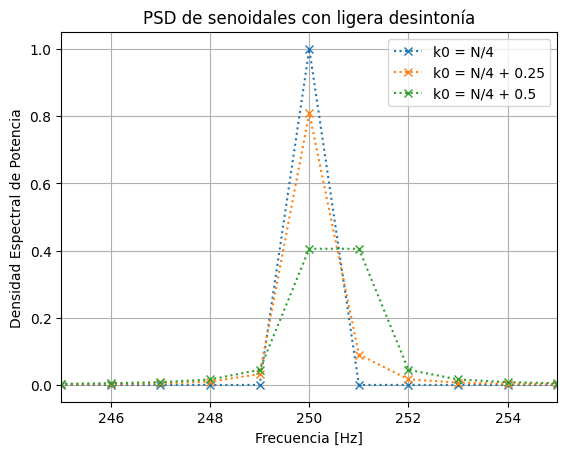

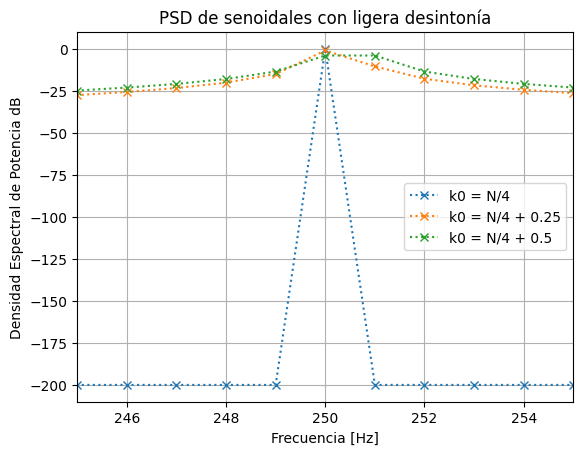

In [20]:

# %% FFT y PSD
X1 = fft(x1)/N
X2 = fft(x2)/N
X3 = fft(x3)/N

PSD1 = np.abs(X1)**2
PSD2 = np.abs(X2)**2
PSD3 = np.abs(X3)**2

frec = np.arange(N) * df
frec_half = frec[:N//2 + 1]

# PSD unilateral
PSD1_uni = PSD1[:N//2 + 1].copy()
PSD1_uni*= 2

PSD2_uni = PSD2[:N//2 + 1].copy()
PSD2_uni *= 2

PSD3_uni = PSD3[:N//2 + 1].copy()
PSD3_uni *= 2


PSD1_uni_db = 10 * np.log10(PSD1_uni + 1e-20)
PSD2_uni_db = 10 * np.log10(PSD2_uni + 1e-20)
PSD3_uni_db = 10 * np.log10(PSD3_uni + 1e-20)

plt.figure()
plt.plot(frec_half, PSD1_uni,':x', label="k0 = N/4")
plt.plot(frec_half, PSD2_uni,':x', label="k0 = N/4 + 0.25")
plt.plot(frec_half, PSD3_uni,':x', label="k0 = N/4 + 0.5")
plt.xlim(245, 255)
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Densidad Espectral de Potencia")
plt.title("PSD de senoidales con ligera desintonía")
plt.legend()
plt.grid(True)
plt.show()



plt.figure()
plt.plot(frec_half, PSD1_uni_db,':x', label="k0 = N/4")
plt.plot(frec_half, PSD2_uni_db,':x',label="k0 = N/4 + 0.25")
plt.plot(frec_half, PSD3_uni_db,':x', label="k0 = N/4 + 0.5")
plt.xlim(245, 255)
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Densidad Espectral de Potencia dB")
plt.title("PSD de senoidales con ligera desintonía")
plt.legend()
plt.grid(True)
plt.show()


Aca se verifica la Identidad de Parseval

In [21]:
# %% b) Verificación de Parseval con PSD unilateral

Et1 = np.sum(np.abs(x1)**2)
Ef1_uni = N * np.sum(PSD1_uni)

Et2 = np.sum(np.abs(x2)**2)
Ef2_uni = N * np.sum(PSD2_uni)

Et3 = np.sum(np.abs(x3)**2)
Ef3_uni = N * np.sum(PSD3_uni)

print("Verificación de Parseval usando PSD unilateral:")
print(f" Señal k0=N/4      -> Et = {Et1:.5f}, Ef = {Ef1_uni:.5f}, diferencia = {Et1 - Ef1_uni:.5e}")
print(f" Señal k0=N/4+0.25 -> Et = {Et2:.5f}, Ef = {Ef2_uni:.5f}, diferencia = {Et2 - Ef2_uni:.5e}")
print(f" Señal k0=N/4+0.5  -> Et = {Et3:.5f}, Ef = {Ef3_uni:.5f}, diferencia = {Et3 - Ef3_uni:.5e}")


Verificación de Parseval usando PSD unilateral:
 Señal k0=N/4      -> Et = 1000.00000, Ef = 1000.00000, diferencia = 0.00000e+00
 Señal k0=N/4+0.25 -> Et = 999.00000, Ef = 999.00200, diferencia = -2.00315e-03
 Señal k0=N/4+0.5  -> Et = 1000.00000, Ef = 1000.00400, diferencia = -4.00008e-03


En esta parte se aplico el Zero Padding

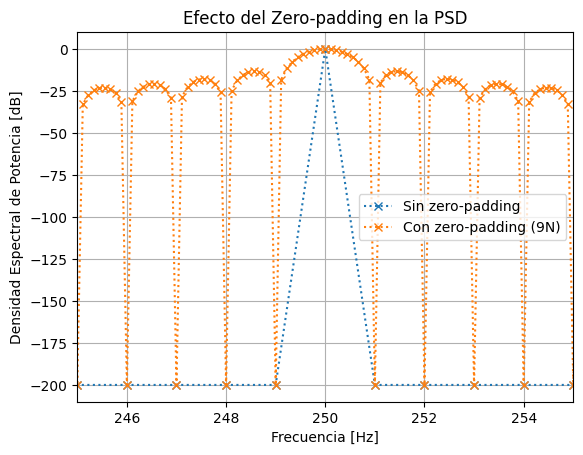

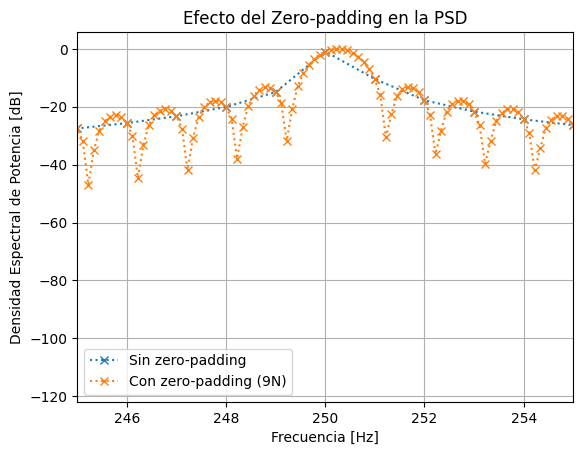

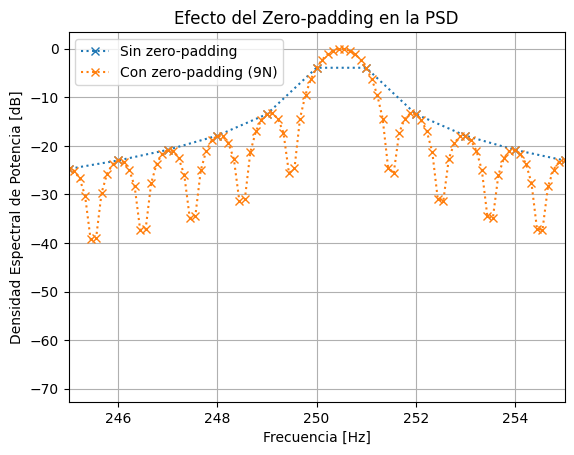

In [22]:
# %% c) Zero padding
cant=9
Npad = cant* N
zz = np.zeros(Npad-N)

# Copiamos x3 al comienzo y el resto queda en cero
zz1 = np.concatenate((x1, zz))
zz2 = np.concatenate((x2, zz))
zz3 = np.concatenate((x3, zz))
# FFT con zero-padding
X1z = fft(zz1)/N
X2z = fft(zz2)/N
X3z = fft(zz3)/N

# Eje de frecuencias
frec_pad = np.arange(Npad) * Fs / Npad
frec_pad_half = frec_pad[:Npad//2 + 1]

# PSD bilateral
PSD1z = np.abs(X1z) **2
PSD2z = np.abs(X2z) **2
PSD3z = np.abs(X3z) **2

# PSD unilateral
PSD1z_uni = PSD1z[:Npad//2 + 1].copy()
PSD1z_uni *= 2

PSD2z_uni = PSD2z[:Npad//2 + 1].copy()
PSD2z_uni *= 2

PSD3z_uni = PSD3z[:Npad//2 + 1].copy()
PSD3z_uni *= 2

PSD1z_uni_db = 10 * np.log10(PSD1z_uni + 1e-20)
PSD2z_uni_db = 10 * np.log10(PSD2z_uni + 1e-20)
PSD3z_uni_db = 10 * np.log10(PSD3z_uni + 1e-20)

# Gráfico comparativo
plt.figure()
plt.plot(frec_half, PSD1_uni_db, ':x', label="Sin zero-padding")
plt.plot(frec_pad_half, PSD1z_uni_db, ':x', label="Con zero-padding (9N)")
plt.xlim(245, 255)
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Densidad Espectral de Potencia [dB]")
plt.title("Efecto del Zero-padding en la PSD")
plt.legend()
plt.grid(True)
plt.show()
plt.figure()
plt.plot(frec_half, PSD2_uni_db, ':x', label="Sin zero-padding")
plt.plot(frec_pad_half, PSD2z_uni_db, ':x', label="Con zero-padding (9N)")
plt.xlim(245, 255)
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Densidad Espectral de Potencia [dB]")
plt.title("Efecto del Zero-padding en la PSD")
plt.legend()
plt.grid(True)
plt.show()
plt.figure()
plt.plot(frec_half, PSD3_uni_db, ':x', label="Sin zero-padding")
plt.plot(frec_pad_half, PSD3z_uni_db, ':x', label="Con zero-padding (9N)")
plt.xlim(245, 255)
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Densidad Espectral de Potencia [dB]")
plt.title("Efecto del Zero-padding en la PSD")
plt.legend()
plt.grid(True)
plt.show()

# Conclusiones
En la primera parte se analizó la PSD de tres senoidales con frecuencias $N/4$, $N/4+0.25$ y $N/4+0.5$. Para el caso $k_0=N/4$, la frecuencia coincide exactamente con un bin de la DFT, por lo que dentro de la ventana de análisis entra un número entero de ciclos. Como consecuencia, la energía se concentra en un único bin, sin presentar desparramo espectral apreciable.En cambio, para las señales con frecuencias $N/4+0.25$ y $N/4+0.5$, la frecuencia no coincide exactamente con la grilla de la DFT. Esto provoca desintonía espectral: la señal no resulta periódica dentro de la ventana observada y la energía se reparte entre varios bins vecinos. Este efecto se conoce como desparramo espectral o *spectral leakage*, y se observa en la PSD como un lóbulo principal acompañado por lóbulos laterales.

Luego se verificó la identidad de Parseval, comprobando que la energía calculada en el dominio temporal coincide con la energía obtenida en el dominio frecuencial, demostrando que la DFT no modifica la energía total de la señal, sino que solo cambia la manera en que dicha energía se distribuye en frecuencia.

Finalmente, al aplicar zero padding hasta $9N$ muestras, se observó que no se agrega información nueva ni se elimina el desparramo espectral. El zero padding solamente aumenta la cantidad de puntos de evaluación de la transformada, generando una grilla de frecuencias más densa. Por eso, el espectro se ve más suave y detallado. Pero con la señal $x_1$, que originalmente no mostraba desparramo porque su frecuencia coincidía exactamente con un bin, al aplicar zero padding aparece una forma similar a una sinc. Esto no significa que el zero padding haya generado nuevo desparramo, sino que ahora se están evaluando frecuencias intermedias entre los bins originales. En la DFT sin padding, esos puntos no se veían porque la grilla caía justo sobre el máximo y sobre los ceros del espectro..